In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob
import wepy as we
import pandas as pd
from impedance.models.circuits import CustomCircuit

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
df = we.basics.read_file(r"C:\Users\Herman\Desktop\CV\IV_Day8_H2_from_II_03_CV_C01.mpt")

In [6]:
print(df)

       mode  ox/red  error  control changes  counter inc.      time/s  \
0         2       0      0                0             0  308.354592   
1         2       0      0                1             0  308.360092   
2         2       0      0                1             0  308.370092   
3         2       0      0                1             0  308.380092   
4         2       0      0                1             0  308.390092   
...     ...     ...    ...              ...           ...         ...   
26095     2       0      0                1             1  570.212286   
26096     2       0      0                1             1  570.222286   
26097     2       0      0                1             1  570.232286   
26098     2       0      0                1             1  570.241786   
26099     2       0      0                0             1  570.246786   

       control/V     Ewe/V     <I>/mA  cycle number  (Q-Qo)/C  I Range  \
0       0.988143  0.987277 -34.294117           1

In [8]:
cycles = np.unique(df["cycle number"].values)
print(cycles)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]


In [20]:
def return_avg(df,cycle, E_range):
    E_CV = (df.loc[df["cycle number"] == cycle, 'control/V'].values)
    I_CV = (df.loc[df["cycle number"] == cycle, '<I>/mA'].values)

    mask = (E_CV > E_range[0]) & (E_CV <= E_range[1])
    E = E_CV[mask]
    I = I_CV[mask]

    mask_p =  np.diff(E) > 0
    mask_p = np.append(mask_p,False)
    mask_m =  np.diff(E) < 0
    mask_m = np.append(mask_m,False)
    E_p = E[mask_p]
    E_m = E[mask_m]
    I_p = I[mask_p]
    I_m = I[mask_m]

    i_p_avg = np.mean(I_p)
    i_m_avg = np.mean(I_m)
    return i_p_avg,i_m_avg

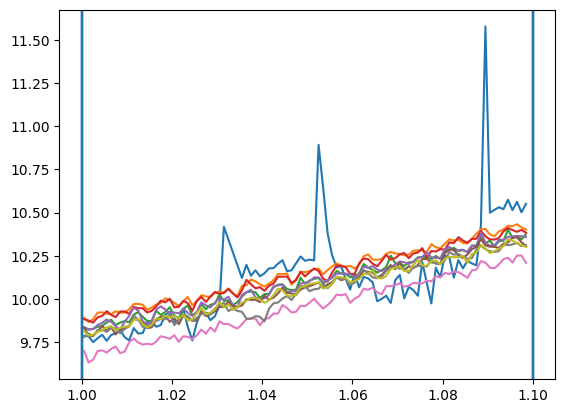

In [19]:
E_range = [1,1.1]
i_p = []
i_m = []
for cycle in cycles[1:-1]:
    i_p_avg,i_m_avg = return_avg(df,cycle,E_range)
    i_p.append(i_p_avg)
    i_m.append(i_m_avg)
    
    # plt.xlim(E_range[0],E_range[1])
    
    # plt.show()